# 6. Stock screen: what the strategy would long and short today

Notebooks 01–04 load the data and prove the strategy out of sample. This notebook answers the practical question:
**given everything in the database right now, which stocks does the momentum + ML-value strategy want to be long,
and which short?**

For the as-of date (the latest priced day, or any date you choose) it:

1. takes the **point-in-time index members** with both signals available,
2. computes **12-1 momentum** and the **ML value** prediction (models are trained on all *completed* history up to
   the as-of date, or reused from disk), and blends them exactly as the backtest does,
3. ranks the universe: **top decile → LONG, bottom decile → SHORT**, equal-weighted and dollar-neutral,
4. enriches each name with ticker, sector, price, market cap, key ratios and **data-quality flags**,
5. shows the **watch-list** just outside each leg, the **sector tilt** of the book and the **changes since last month**,
6. exports the screen to `toolkit/files/screens/` (CSV, plus Excel when `openpyxl` is installed).

| Step | Library call |
|---|---|
| Point-in-time fundamentals | `StaticFundamentalsProvider(availability_lag_days=...)` |
| Signals | `MomentumFactor`, `MLReturnFactor.score_panel` |
| Screen | `analytics.screening.build_screen` → `enrich_screen` → `add_quality_flags` |
| Reading it | `watchlist`, `sector_exposure`, `screen_changes`, `summarize_screen` |

Nothing is written to the database unless `WRITE_FACTOR_SCORES = True`.
Set `OFFLINE_DEMO = True` to run on synthetic data without a database (tickers then look like `SYN1001.O`).

## 6.1 Parameters

In [1]:
AS_OF = None                        # "YYYY-MM-DD" or None = latest priced date in the database
UNIVERSE = "SP500"                  # portfolio whose point-in-time members are eligible
HISTORY_YEARS = 7                   # price history loaded before AS_OF (momentum needs 13 months; the rest trains the ML model)
SOURCE_VENDOR = "refinitiv"

# --- strategy definition (keep in line with notebook 04) ---
QUANTILE = 0.10                     # top / bottom decile
FACTOR_WEIGHTS = {"momentum": 0.3, "ml_value": 0.7}
BLEND_METHOD = "zscore"             # "zscore" or "rank"
MOMENTUM_LOOKBACK, MOMENTUM_SKIP = 252, 21
FORWARD_MONTHS = 3                  # ML label horizon
AVAILABILITY_LAG_DAYS = 45          # a fiscal period's ratios become usable this many days after the period end
REQUIRE_ALL_SIGNALS = True          # drop names lacking momentum history or fundamentals instead of scoring them as average
MAX_WEIGHT = None                   # optional per-name cap, e.g. 0.05

# --- ML model management ---
RETRAIN = False                     # True: refit on all completed history up to AS_OF; False: reuse persisted models when present
TEST_SIZE, EMBARGO_MONTHS = 0.2, FORWARD_MONTHS

# --- reporting ---
STALE_FUNDAMENTALS_DAYS = 200       # flag names whose latest fiscal period end is older than this
WATCHLIST_BAND = 0.05               # names within 5% of the universe of each cut-off
PREVIOUS_SCREEN_DAYS = 21           # compare with the screen ~one month earlier
WRITE_FACTOR_SCORES = False         # persist the as-of scores to analytics.factor_scores
OFFLINE_DEMO = False                # True: synthetic data, no database

## 6.2 Imports

In [2]:
import sys
import os

import pandas as pd

# Get the current notebook's directory and go up to parent
current_dir = os.getcwd()
parent_dir = os.path.dirname(os.path.dirname(current_dir))

if parent_dir not in sys.path:
    sys.path.append(parent_dir)

print(f"Current directory: {current_dir}")
print(f"Added to path: {parent_dir}")
data_eng_path = os.path.join(parent_dir, 'data_engineering')
files_path = os.path.join(parent_dir, 'toolkit\\files')
print(f"Data engineering folder exists: {os.path.exists(data_eng_path)}")
print(f"Files folder exists: {os.path.exists(files_path)}")

Current directory: c:\SourceCode\InvestmentManagement\toolkit\notebooks
Added to path: c:\SourceCode\InvestmentManagement
Data engineering folder exists: True
Files folder exists: True


In [3]:
import logging
import os

import numpy as np
import pandas as pd
from IPython.display import display

import analytics
from analytics.data_quality import neutralize_single_day_glitches
from analytics.factors import DEFAULT_ENSEMBLE, MODELS_DIR, MLReturnFactor, MomentumFactor, ValueFactor, models_available
from analytics.factors import ml_training
from analytics.performance.plots import plot_score_distribution, plot_screen_scatter
from analytics.screening import (
    add_quality_flags, build_screen, enrich_screen, export_screen, factor_score_rows, screen_changes,
    sector_exposure, summarize_screen, watchlist,
)

logging.basicConfig(level=logging.INFO, format="%(asctime)s %(levelname)s %(name)s: %(message)s")
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

PROJECT_ROOT = os.path.dirname(os.path.dirname(os.path.abspath(analytics.__file__)))
EXPORT_DIR = os.path.join(PROJECT_ROOT, "toolkit", "files", "screens")
MODEL_DIR = os.path.join(MODELS_DIR, UNIVERSE.lower() + ("_demo" if OFFLINE_DEMO else ""))

## 6.3 Data

Either from the database (prices for every security ever held by `UNIVERSE`, the security master and Refinitiv
tickers, daily holdings for point-in-time membership, float-adjusted shares for market cap, and the fundamentals
provider) or, with `OFFLINE_DEMO = True`, from the synthetic generators used by the unit tests.
Everything after this cell is identical in both modes.

In [4]:
if OFFLINE_DEMO:
    from data_engineering.fundamentals import InMemoryFundamentalsProvider
    from tests.unit_tests.synthetic import (
        synthetic_fundamentals_history, synthetic_membership, synthetic_prices, synthetic_security_master, synthetic_shares_outstanding,
    )

    session = engine = connection = None
    prices_full = synthetic_prices(n_securities=120, n_days=int(HISTORY_YEARS * 252), seed=21)
    quarter_ends = pd.date_range(prices_full.index[0] - pd.offsets.QuarterEnd(2), prices_full.index[-1], freq="QE")
    history = synthetic_fundamentals_history(list(prices_full.columns), quarter_ends, seed=3)
    history = history[~history["security_id"].isin(list(prices_full.columns)[40:46])]        # six members with no fundamentals at all
    provider = InMemoryFundamentalsProvider(history, availability_lag_days=AVAILABILITY_LAG_DAYS)
    security_master = synthetic_security_master(list(prices_full.columns))
    tickers = security_master.set_index("security_id")["vendor_ticker"]
    members_on = synthetic_membership(prices_full)
    shares_history = synthetic_shares_outstanding(list(prices_full.columns)).rename("metric_value").reset_index().assign(effective_date=prices_full.index[0])
else:
    from data_engineering.database import database
    from data_engineering.fundamentals import StaticFundamentalsProvider
    from data_engineering.loaders.portfolios import portfolio_member_ids, portfolio_members_on

    engine, connection, conn_str, session = database.get_db_connection()
    end_date = pd.Timestamp(AS_OF) if AS_OF else pd.Timestamp.today().normalize()
    start_date = end_date - pd.DateOffset(years=HISTORY_YEARS)

    universe_ids = portfolio_member_ids(engine, UNIVERSE)
    raw = database.read_market_data(session, engine, start_date.strftime("%Y-%m-%d"), end_date.strftime("%Y-%m-%d"))
    raw["as_of_date"] = pd.to_datetime(raw["as_of_date"])
    prices_full = raw.pivot_table(index="as_of_date", columns="security_id", values="adj_close").sort_index()
    prices_full = prices_full[[c for c in universe_ids if c in prices_full.columns]]

    provider = StaticFundamentalsProvider(session, engine, source_vendor=SOURCE_VENDOR, availability_lag_days=AVAILABILITY_LAG_DAYS)
    security_master = database.read_security_master(session, engine)
    xref = database.read_security_vendor_xref(session, engine, vendor="Refinitiv").sort_values("is_primary", ascending=False)
    tickers = xref.drop_duplicates("security_id").set_index("security_id")["vendor_ticker"]
    members_on = portfolio_members_on(engine, UNIVERSE)
    shares_history = database.read_security_fundamentals(session, engine, "shares_outstanding")
    shares_history = shares_history.rename(columns={"shares_outstanding": "metric_value"})

print(f"price panel: {prices_full.shape[0]} days x {prices_full.shape[1]} securities, {prices_full.index[0].date()} -> {prices_full.index[-1].date()}")

Database connection successful.
price panel: 1674 days x 604 securities, 2020-01-02 -> 2026-08-31


## 6.4 As-of date and the eligible universe

Prices are cleaned of one-day glitch prints first. The eligible universe is the set of `UNIVERSE` members on the
as-of date (from the daily holdings); `REQUIRE_ALL_SIGNALS` later removes members without 13 months of price
history or without any fundamentals.

In [5]:
prices_full, n_glitches = neutralize_single_day_glitches(prices_full, threshold=0.5)
priced_dates = prices_full.index[prices_full.notna().sum(axis=1) >= 0.5 * prices_full.shape[1]]   # ignore holiday stubs
as_of = priced_dates[-1] if AS_OF is None else priced_dates[priced_dates <= pd.Timestamp(AS_OF)][-1]
previous_date = priced_dates[max(0, priced_dates.get_loc(as_of) - PREVIOUS_SCREEN_DAYS)]

member_dates = pd.DatetimeIndex(members_on.index) if members_on is not None else pd.DatetimeIndex([])


def members(date):
    """Point-in-time members of UNIVERSE on ``date`` (latest holdings snapshot on or before it)."""
    if members_on is None or not len(member_dates):
        return set(prices_full.columns)
    prior = member_dates[member_dates <= date]
    return {int(s) for s in members_on.loc[prior[-1]]} if len(prior) else set()


eligible_now, eligible_prev = members(as_of), members(previous_date)
all_symbols = pd.DataFrame({"security_id": prices_full.columns})
print(f"as-of {as_of.date()} (previous screen {previous_date.date()}) | glitch prints neutralised: {n_glitches}")
print(f"{UNIVERSE} members on the as-of date: {len(eligible_now)} ({len(eligible_now & set(prices_full.columns))} with prices)")

as-of 2026-08-31 (previous screen 2026-07-31) | glitch prints neutralised: 0
SP500 members on the as-of date: 503 (503 with prices)


## 6.5 Momentum

12-1 momentum: return from t-273 to t-21 trading days. The raw value is kept for the screen; the composite uses
its cross-sectional z-score.

In [6]:
momentum = MomentumFactor(MOMENTUM_LOOKBACK, MOMENTUM_SKIP).compute(prices_full)
print(f"momentum defined for {int(momentum.loc[as_of].notna().sum())} of {prices_full.shape[1]} securities on {as_of.date()}")

momentum defined for 597 of 604 securities on 2026-08-31


## 6.6 ML value

The models predict the next `FORWARD_MONTHS` return **relative to the cross-section** from the 18 ratios.
Training uses every monthly snapshot whose forward window has *completed* before the as-of date (later snapshots
have no label yet and are dropped automatically), a time-based split with an embargo, and the three tree ensembles.
Persisted models under `analytics/factors/models/<universe>/` are reused unless `RETRAIN = True`; the metadata file
records what they were trained on.

In [7]:
if RETRAIN or not models_available(MODEL_DIR, DEFAULT_ENSEMBLE):
    train_start = (as_of - pd.DateOffset(years=HISTORY_YEARS - 1)).strftime("%Y-%m-%d")
    table = ml_training.build_modelling_table_from_panel(
        prices_full.loc[:as_of], provider, all_symbols, train_start, as_of.strftime("%Y-%m-%d"),
        forward_months=FORWARD_MONTHS, demean_target=True,
    )
    print(f"modelling rows: {len(table):,} | securities: {table['security_id'].nunique()} | "
          f"snapshots {table['snapshot_date'].min().date()} -> {table['snapshot_date'].max().date()}")
    metrics = ml_training.train_models(table, model_keys=DEFAULT_ENSEMBLE, model_dir=MODEL_DIR, test_size=TEST_SIZE, embargo_months=EMBARGO_MONTHS, verbose=False)
    ml_training.save_training_metadata(MODEL_DIR, {
        "trained_on": pd.Timestamp.now().strftime("%Y-%m-%d %H:%M"), "as_of": str(as_of.date()), "universe": UNIVERSE,
        "rows": int(len(table)), "securities": int(table["security_id"].nunique()),
        "snapshot_range": [str(table["snapshot_date"].min().date()), str(table["snapshot_date"].max().date())],
        "forward_months": FORWARD_MONTHS, "availability_lag_days": AVAILABILITY_LAG_DAYS, "demean_target": True,
        "test_size": TEST_SIZE, "embargo_months": EMBARGO_MONTHS, "models": DEFAULT_ENSEMBLE, "metrics": metrics,
    })
    display(pd.DataFrame(metrics).T)
else:
    meta = ml_training.load_training_metadata(MODEL_DIR) or {}
    print(f"reusing persisted models from {MODEL_DIR}: trained {meta.get('trained_on', '?')} on data to {meta.get('as_of', '?')} "
          f"({meta.get('rows', '?')} rows). Set RETRAIN = True to refit.")

reusing persisted models from c:\SourceCode\InvestmentManagement\analytics\factors\models\sp500: trained 2026-09-20 21:35 on data to 2026-08-31 (40910 rows). Set RETRAIN = True to refit.


In [8]:
ml_factor = MLReturnFactor(mode="ensemble", model_dir=MODEL_DIR, score_missing=False)   # names with no ratios at all get NaN, not "average"


def ml_scores_on(date):
    return ml_factor.score_panel(provider.get_panel(all_symbols, date.strftime("%Y-%m-%d")))


ml_value = pd.DataFrame({d: ml_scores_on(d) for d in (previous_date, as_of)}).T
print(f"ML value scored for {int(ml_value.loc[as_of].notna().sum())} securities on {as_of.date()} "
      f"(predicted relative {FORWARD_MONTHS}m return: median {ml_value.loc[as_of].median():+.2%}, "
      f"spread top/bottom decile {ml_value.loc[as_of].quantile(0.9) - ml_value.loc[as_of].quantile(0.1):+.2%})")

ML value scored for 604 securities on 2026-08-31 (predicted relative 3m return: median +1.29%, spread top/bottom decile +33.16%)


## 6.7 The screen

`build_screen` z-scores each signal across the eligible names, averages them with `FACTOR_WEIGHTS`, ranks the
result and assigns the top decile to LONG and the bottom decile to SHORT with equal weights (+1 / −1 per leg).
The same call on `previous_date` gives last month's book for the change report.

In [9]:
components = {"momentum": momentum.loc[[previous_date, as_of]], "ml_value": ml_value}
common = dict(quantile=QUANTILE, weights=FACTOR_WEIGHTS, method=BLEND_METHOD, require_all=REQUIRE_ALL_SIGNALS, max_weight=MAX_WEIGHT)
screen = build_screen(components, as_of, eligible=eligible_now, **common)
previous = build_screen(components, previous_date, eligible=eligible_prev, **common)

dropped = len(eligible_now & set(prices_full.columns)) - len(screen)
print(f"eligible names scored: {len(screen)} ({dropped} members dropped for missing momentum history or fundamentals)")

eligible names scored: 500 (3 members dropped for missing momentum history or fundamentals)


### Enrichment

Ticker, name and sector from the security master; the as-of price; market cap from the latest float-adjusted
shares; the key ratios from the *point-in-time* panel the model actually saw; the latest fiscal period end behind
those ratios; a transparent `value_ref` score (mean z of E/P, B/P, S/P, EBIT/EV) for a sanity check against the
ML prediction; and data-quality flags.

In [10]:
panel_now = provider.get_panel(all_symbols, as_of.strftime("%Y-%m-%d"))
shares_history["effective_date"] = pd.to_datetime(shares_history["effective_date"])
shares_now = (shares_history[shares_history["effective_date"] <= as_of].sort_values("effective_date")
              .groupby("security_id")["metric_value"].last())

screen = enrich_screen(
    screen, as_of,
    security_master=security_master, tickers=tickers, prices=prices_full.loc[as_of],
    ratios=panel_now, shares_outstanding=shares_now, fundamentals_date=provider.latest_effective_dates(all_symbols, as_of),
)
screen["value_ref"] = ValueFactor().score_panel(panel_now).reindex(screen.index)
screen = add_quality_flags(screen, stale_days=STALE_FUNDAMENTALS_DAYS)
previous = enrich_screen(previous, previous_date, security_master=security_master, tickers=tickers)

summary = summarize_screen(screen)
print(f"{summary['n_long']} longs / {summary['n_short']} shorts out of {summary['n_eligible']} eligible names | "
      f"gross {summary['gross_exposure']:.2f}, net {summary['net_exposure']:+.2f} | "
      f"{summary['n_selected_with_flags']} selected names carry a data-quality flag")

SHOW = ["ticker", "name", "sector", "rank", "weight", "composite", "momentum_score", "ml_value_score", "momentum_raw", "ml_value_raw",
        "value_ref", "price", "market_cap", "P/E", "P/B", "EV/EBIT", "fundamentals_date", "flags"]
SHOW = [c for c in SHOW if c in screen.columns]

50 longs / 50 shorts out of 500 eligible names | gross 2.00, net -0.00 | 96 selected names carry a data-quality flag


### LONG book (highest composite score)

In [11]:
longs = screen[screen["side"] == "LONG"]
display(longs[SHOW])

,ticker,name,sector,rank,weight,composite,momentum_score,ml_value_score,momentum_raw,ml_value_raw,value_ref,price,market_cap,P/E,P/B,EV/EBIT,fundamentals_date,flags
security_id,,,,,,,,,,,,,,,,,,
518,SNDK.OQ,SNDK.OQ,None,1,0.020,6.400,19.312,0.866,26.998,0.186,NaN,"1,566.700","229,394,648,866.700",NaN,NaN,NaN,2025-06-27,stale fundamentals (430d)
408,MU.OQ,MU.OQ,None,2,0.020,2.595,4.264,1.879,6.173,0.314,NaN,958.730,"1,082,783,095,658.230",NaN,NaN,NaN,2025-08-28,stale fundamentals (368d)
305,INTC.OQ,INTC.OQ,None,3,0.020,1.994,2.286,1.868,3.435,0.313,NaN,89.510,"473,066,571,929.610",NaN,NaN,NaN,2025-12-27,stale fundamentals (247d)
353,LITE.OQ,LITE.OQ,None,4,0.020,1.988,3.777,1.221,5.499,0.231,NaN,914.760,"82,053,972,000.000",NaN,NaN,NaN,2025-06-28,stale fundamentals (429d)
112,CIEN.N,CIEN.N,None,5,0.020,1.892,2.012,1.841,3.056,0.309,NaN,382.800,"54,284,303,370.000",NaN,NaN,NaN,2025-11-01,stale fundamentals (303d)
163,DELL.N,DELL.N,None,6,0.020,1.777,1.275,1.992,2.036,0.329,NaN,456.010,"294,647,408,592.280",NaN,NaN,NaN,2026-01-30,stale fundamentals (213d)
593,VRSN.OQ,VRSN.OQ,None,7,0.020,1.716,-0.134,2.508,0.086,0.394,-0.454,288.280,"26,031,684,000.000",27.040,-10.364,21.512,2025-12-31,stale fundamentals (243d)
499,ROST.OQ,ROST.OQ,None,8,0.020,1.674,0.391,2.224,0.813,0.358,NaN,228.540,"73,007,813,759.400",NaN,NaN,NaN,2026-01-31,stale fundamentals (212d)
360,LRCX.OQ,LRCX.OQ,None,9,0.020,1.667,1.218,1.859,1.957,0.312,NaN,301.490,"377,260,768,290.000",NaN,NaN,NaN,2025-06-29,stale fundamentals (428d)


### SHORT book (lowest composite score)

In [12]:
shorts = screen[screen["side"] == "SHORT"].sort_values("rank", ascending=False)
display(shorts[SHOW])

,ticker,name,sector,rank,weight,composite,momentum_score,ml_value_score,momentum_raw,ml_value_raw,value_ref,price,market_cap,P/E,P/B,EV/EBIT,fundamentals_date,flags
security_id,,,,,,,,,,,,,,,,,,
284,HOOD.OQ,HOOD.OQ,None,500,-0.020,-0.742,-0.329,-0.919,-0.184,-0.041,-0.922,104.810,"94,232,813,033.130",54.137,11.153,52.335,2025-12-31,stale fundamentals (243d)
467,PNR.N,PNR.N,None,499,-0.020,-0.714,-0.452,-0.826,-0.354,-0.029,-0.381,60.460,"9,651,710,457.000",26.001,4.394,18.715,2025-12-31,stale fundamentals (243d)
102,CDW.OQ,CDW.OQ,None,498,-0.020,-0.703,-0.325,-0.865,-0.179,-0.034,0.153,151.580,"18,950,141,433.080",16.625,6.804,12.655,2025-12-31,stale fundamentals (243d)
396,MRNA.OQ,MRNA.OQ,None,497,-0.020,-0.684,0.313,-1.111,0.705,-0.066,0.220,140.340,"56,028,764,662.260",-4.083,1.332,-4.368,2025-12-31,stale fundamentals (243d)
533,SWKS.OQ,SWKS.OQ,None,496,-0.020,-0.682,-0.288,-0.850,-0.127,-0.032,0.046,67.010,"10,083,181,121.820",15.990,2.583,14.163,2025-10-03,stale fundamentals (332d)
315,IT.N,IT.N,None,495,-0.020,-0.671,-0.601,-0.701,-0.561,-0.013,-0.483,198.110,"12,510,443,635.360",24.935,56.840,17.929,2025-12-31,stale fundamentals (243d)
234,FISV.OQ,FISV.OQ,None,494,-0.020,-0.667,-0.642,-0.678,-0.617,-0.010,0.722,53.310,"28,348,483,896.510",10.381,1.401,11.429,2025-12-31,stale fundamentals (243d)
566,TYL.N,TYL.N,None,493,-0.020,-0.665,-0.515,-0.729,-0.442,-0.017,-0.855,372.220,"15,243,255,428.280",61.889,5.275,56.174,2025-12-31,stale fundamentals (243d)
416,NFLX.OQ,NFLX.OQ,None,492,-0.020,-0.663,-0.481,-0.740,-0.394,-0.018,-0.762,81.050,"337,487,310,739.800",36.050,14.874,30.790,2025-12-31,stale fundamentals (243d)


### Watch-list

Unselected names within `WATCHLIST_BAND` of each cut-off: the next candidates to enter if a position is closed, and
the names most likely to enter at the next rebalance.

In [13]:
watch = watchlist(screen, band=WATCHLIST_BAND)
display(watch[["watch"] + [c for c in SHOW if c not in ("flags",)]])

,watch,ticker,name,sector,rank,weight,composite,momentum_score,ml_value_score,momentum_raw,ml_value_raw,value_ref,price,market_cap,P/E,P/B,EV/EBIT,fundamentals_date
security_id,,,,,,,,,,,,,,,,,,
287,NEAR LONG,HPQ.N,HPQ.N,None,51,0.000,1.323,-0.134,1.947,0.086,0.323,NaN,30.020,"27,071,764,889.380",NaN,NaN,NaN,2025-10-31
1,NEAR LONG,A.N,A.N,None,52,0.000,1.302,-0.072,1.890,0.172,0.316,NaN,153.560,"43,292,994,820.240",NaN,NaN,NaN,2025-10-31
323,NEAR LONG,JNJ.N,JNJ.N,None,53,0.000,1.298,0.189,1.773,0.533,0.301,NaN,265.850,"640,671,542,012.450",NaN,NaN,NaN,2025-12-28
100,NEAR LONG,CCL.N,CCL.N,None,54,0.000,1.297,-0.252,1.961,-0.077,0.325,NaN,23.890,"32,720,917,452.910",NaN,NaN,NaN,2025-11-30
271,NEAR LONG,HAS.OQ,HAS.OQ,None,55,0.000,1.289,-0.026,1.853,0.236,0.311,NaN,94.100,"13,272,284,344.700",NaN,NaN,NaN,2025-12-28
413,NEAR LONG,NDSN.OQ,NDSN.OQ,None,56,0.000,1.289,0.079,1.808,0.380,0.305,NaN,321.720,"17,919,600,029.520",NaN,NaN,NaN,2025-10-31
494,NEAR LONG,RL.N,RL.N,None,57,0.000,1.282,-0.012,1.837,0.254,0.309,NaN,346.900,"20,669,078,709.100",NaN,NaN,NaN,2026-03-28
506,NEAR LONG,SBUX.OQ,SBUX.OQ,None,58,0.000,1.281,-0.099,1.872,0.135,0.313,NaN,106.250,"121,125,000,000.000",NaN,NaN,NaN,2025-09-28
10,NEAR LONG,ACN.N,ACN.N,None,59,0.000,1.268,-0.481,2.017,-0.394,0.332,NaN,189.760,"116,122,134,603.840",NaN,NaN,NaN,2025-08-31


### Sector tilt of the book

The strategy is dollar-neutral overall but not sector-neutral: a large net weight in one sector means the book is
partly a sector bet. `neutralize` (sector-demeaned scores) is the fix if that is unwanted - see
`docs/STRATEGY_IMPROVEMENTS.md` B.3.

In [14]:
display(sector_exposure(screen))

,n_eligible,n_long,n_short,long_weight,short_weight,net_weight
sector,,,,,,
Unknown,500,50,50,1.000,-1.000,0.000


## 6.8 Changes since the previous screen

Trades the strategy would make versus its book on `previous_date`: new entries, exits and side flips. Names that
left the index count as exits.

In [15]:
changes = screen_changes(screen, previous)
print(changes["change"].value_counts().to_string() if len(changes) else "no changes")
display(changes)

change
ENTER SHORT    5
EXIT SHORT     5
ENTER LONG     3
EXIT LONG      3


,previous_side,current_side,change,ticker,name,current_composite,current_weight
security_id,,,,,,,
425,,LONG,ENTER LONG,NTAP.OQ,NTAP.OQ,1.391,0.020
503,,LONG,ENTER LONG,RVTY.N,RVTY.N,1.335,0.020
57,,LONG,ENTER LONG,AVGO.OQ,AVGO.OQ,1.324,0.020
329,,SHORT,ENTER SHORT,KDP.OQ,KDP.OQ,-0.563,-0.020
637,,SHORT,ENTER SHORT,ZTS.N,ZTS.N,-0.565,-0.020
79,,SHORT,ENTER SHORT,BLDR.N,BLDR.N,-0.572,-0.020
497,,SHORT,ENTER SHORT,ROL.N,ROL.N,-0.589,-0.020
351,,SHORT,ENTER SHORT,LII.N,LII.N,-0.614,-0.020
100,LONG,,EXIT LONG,CCL.N,CCL.N,1.297,0.000


## 6.9 Pictures

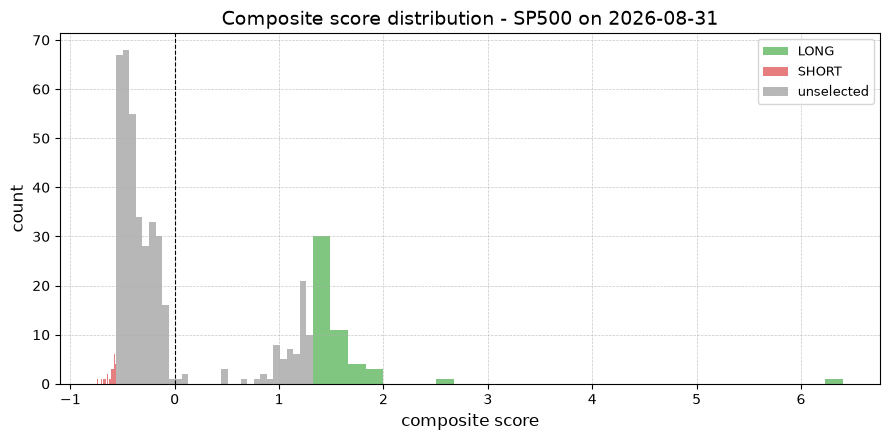

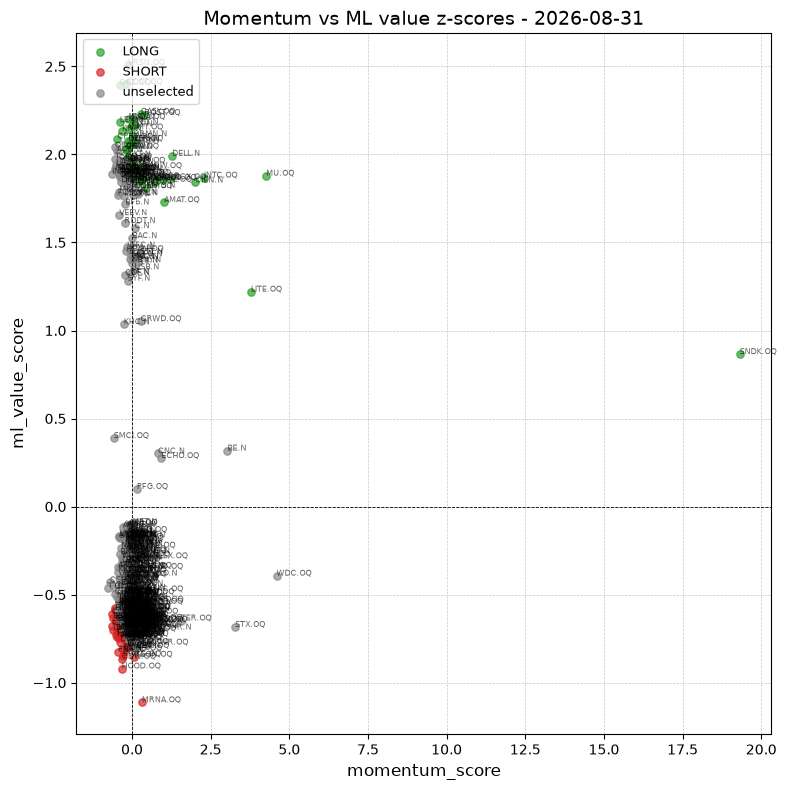

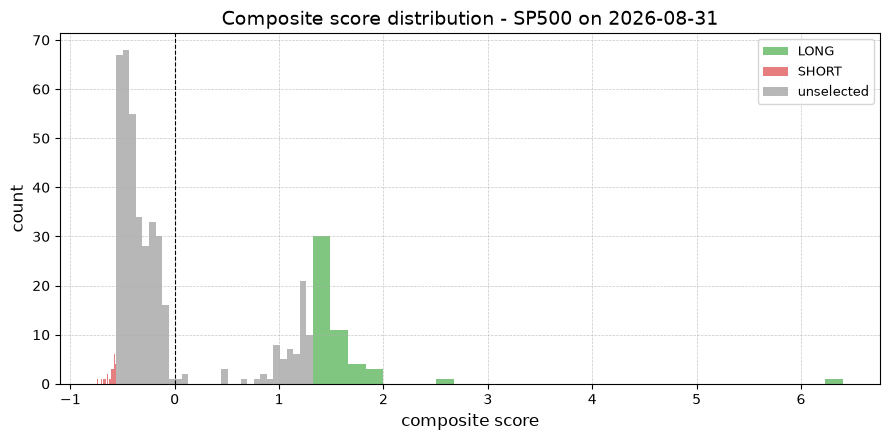

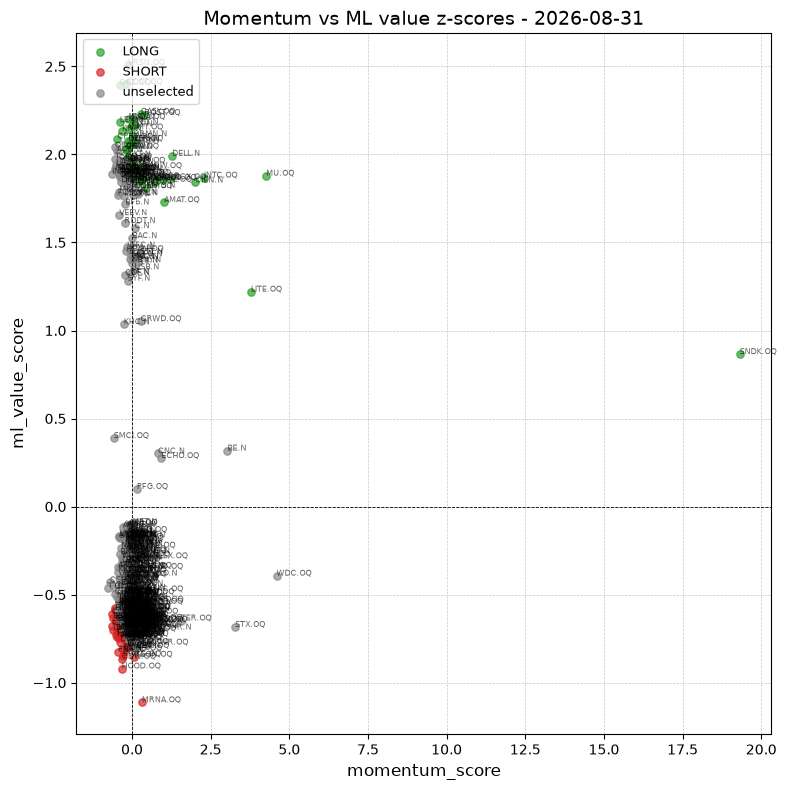

In [16]:
display(plot_score_distribution(screen, title=f"Composite score distribution - {UNIVERSE} on {as_of.date()}"))
display(plot_screen_scatter(screen, "momentum_score", "ml_value_score", title=f"Momentum vs ML value z-scores - {as_of.date()}"))

## 6.10 Export (and optional persistence)

The full screen - every eligible name with scores, side, weight, ratios and flags - goes to
`toolkit/files/screens/screen_<universe>_<as-of>.csv` (plus `.xlsx` when `openpyxl` is installed). With
`WRITE_FACTOR_SCORES = True` the as-of raw signals and composite are also upserted into `analytics.factor_scores`.

In [17]:
written = export_screen(screen, EXPORT_DIR, as_of, label=f"screen_{UNIVERSE.lower()}")
written += export_screen(changes, EXPORT_DIR, as_of, label=f"changes_{UNIVERSE.lower()}", excel=False)
print("written:", *written, sep="\n  ")

if WRITE_FACTOR_SCORES and session is not None:
    rows = factor_score_rows(screen, UNIVERSE, SOURCE_VENDOR)
    database.write_factor_scores(rows, session)
    print(f"upserted {len(rows)} factor_scores rows for {as_of.date()}")

if session is not None:
    session.close()
    connection.close()

written:
  c:\SourceCode\InvestmentManagement\toolkit\files\screens\screen_sp500_2026-08-31.csv
  c:\SourceCode\InvestmentManagement\toolkit\files\screens\screen_sp500_2026-08-31.xlsx
  c:\SourceCode\InvestmentManagement\toolkit\files\screens\changes_sp500_2026-08-31.csv


## 6.11 How to read the screen

* **Both scores matter.** A name in the LONG book with a negative `ml_value_score` is there on momentum alone
  (and vice versa); the scatter in 6.9 shows this at a glance. `value_ref` is the plain price-multiple view - a
  LONG with a very negative `value_ref` is the model betting against conventional cheapness.
* **Flags are not vetoes, but read them.** `no fundamentals` names are already excluded when
  `REQUIRE_ALL_SIGNALS = True`; `stale fundamentals` means the ML score rests on an old filing (a late filer, a
  recent listing or a data gap - worth checking before trading).
* **Turnover.** The change report is the trade list. If it is long every month, consider the holding-period buffer
  in `docs/STRATEGY_IMPROVEMENTS.md` B.5 (only replace a name once it leaves the top/bottom 15 %).
* **This is a research screen, not investment advice.** Sizes are equal-weight targets before liquidity, borrow
  availability, risk limits and costs.